In [1]:
%pip install -U numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import platform

import numpy as np
import pandas as pd

try:
    import sklearn
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)

Python: 3.13.12
Executable: f:\ml-course-homeworks\.venv\Scripts\python.exe
OS: Windows-11-10.0.26200-SP0
NumPy: 2.4.2
Pandas: 3.0.1
scikit-learn: 1.8.0


Значения для всей матрицы: 
Среднее арифмитическое: 0.5065578893311851
Стандартное отклонение: 0.2867310873519535
Мин значение: 0.0009319217169800886
Макс значение: 0.9997797491477372
Значения для столбцов в матрице: 
Среднее арифмитическое: 0.5065578893311851
Стандартное отклонение: 0.2867310873519535
Мин значение: 0.0009319217169800886
Макс значение: 0.9997797491477372
        Age       BMI    Height    Gender     State      Risk
0  0.883344  0.892309  0.099242  0.344575  0.508974  1.364268
1  0.575802  0.690771  0.055772  0.525254  0.750604  1.260463
2  0.389571  0.790112  0.728908  0.336588  0.542817  1.426081
3  0.720992  0.707353  0.586278  0.779193  0.398592  1.608478
4  0.204645  0.764448  0.560100  0.756014  0.345850  1.508863
(100, 6)
              Age         BMI      Height      Gender       State        Risk
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000
mean     0.496783    0.538832    0.501198    0.500713    0.495264    1.220272
std      0.

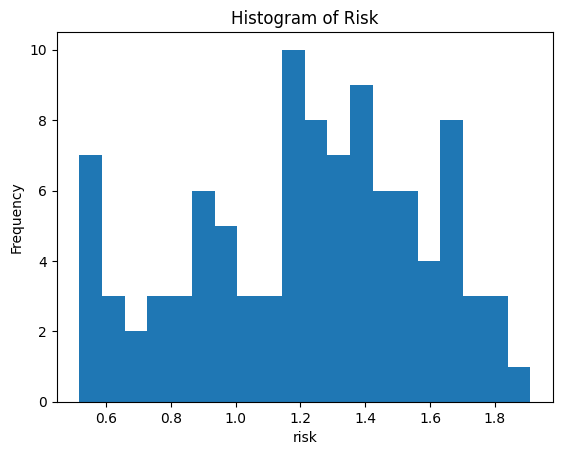

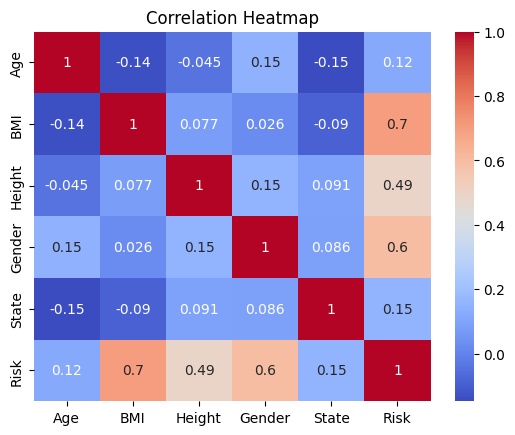

In [7]:
import pandas as pd
import numpy as np

x = np.random.rand(100, 5)

mean_val = x.mean() #Среднее арифмитическое
std_val = x.std()   #Стандартное отклонение
min_val = x.min()   #Мин значение
max_val = x.max() #Макс значение
print(f"Значения для всей матрицы: \nСреднее арифмитическое: {mean_val}\nСтандартное отклонение: {std_val}\n" 
      f"Мин значение: {min_val}\nМакс значение: {max_val}")

mean_val_col = x.mean() #Среднее арифмитическое
std_val_col = x.std()   #Стандартное отклонение
min_val_col = x.min()   #Мин значение
max_val_col = x.max() #Макс значение
print(f"Значения для столбцов в матрице: \nСреднее арифмитическое: {mean_val_col}\nСтандартное отклонение: {std_val_col}\n" 
      f"Мин значение: {min_val_col}\nМакс значение: {max_val_col}")

w = np.random.rand(5) #вектор весов
y = x @ w #векторное усножение

colums_name = ["Age", "BMI", "Height", "Gender", "State"]
df_x = pd.DataFrame(x, columns=colums_name)
df_x["Risk"] = y
print(df_x.head()) #первые 5 строк df
print(df_x.shape) #возвращает кортеж
print(df_x.describe()) #статистика

hight_yung_risk = df_x[(df_x["Age"] < 0.5) & (df_x["Risk"] > 0.7)]
hight_yung_risk_sorted = hight_yung_risk.sort_values(by="BMI", ascending=False)
print(f"Фильтрация:\n {hight_yung_risk}\n Сортировка:\n {hight_yung_risk_sorted}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.hist(df_x["Risk"], bins=20)
plt.xlabel("risk")
plt.ylabel("Frequency")
plt.title("Histogram of Risk")

plt.figure()
sns.heatmap(df_x.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

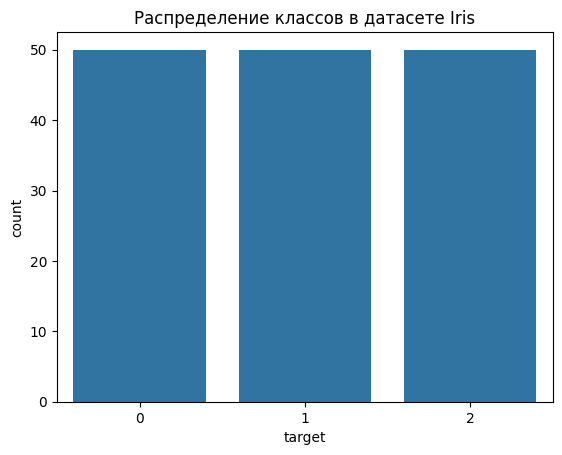

accuracy: 1.0


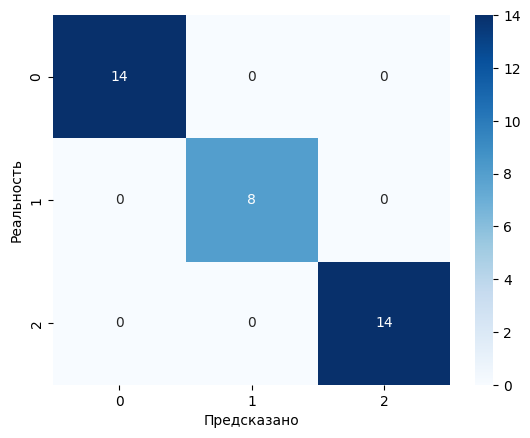

In [ ]:
#Бонусное задание
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["target"] = iris.target
df_iris.head()

sns.countplot(x="target", data=df_iris)
plt.title("Распределение классов в датасете Iris")
plt.show()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df_iris.drop("target", axis=1)
y = df_iris["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.4, random_state=42)

linear_model = LogisticRegression()
linear_model.fit(X_train, y_train) #модель учится
y_pred_test = linear_model.predict(X_test) #модель предсказывает классы из данных которые она не видел

from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred_test)
print(f"accuracy: {accuracy}")
conf_matrix = confusion_matrix(y_test, y_pred_test) #матрица ошибок
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues') 
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()



